<a href="https://colab.research.google.com/github/ANGB022210151/AquacultureProject/blob/main/step_6_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training sequences: 3908
Testing sequences: 977


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8, 64)          │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,236 (122.02 KB)

 Trainable params: 31,236 (122.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0595 - val_loss: 0.0268
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0198 - val_loss: 0.0229
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0181 - val_loss: 0.0198
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0168 - val_loss: 0.0172
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0160 - val_loss: 0.0149
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0152 - val_loss: 0.0138
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0147 - val_loss: 0.0126
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0142 - val_loss: 0.0119
Epoch 9/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0133 - val_loss: 0.0112
Epoch 10/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0131 - val_loss: 0.0106
Epoch 11/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0128 - val_loss: 0.0101
Epoch 12/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0

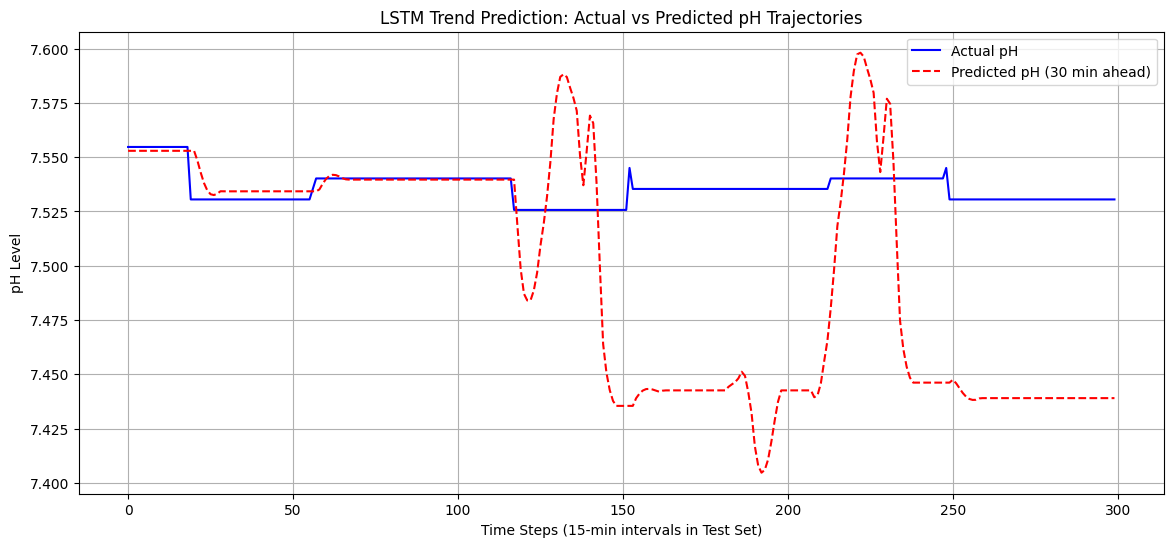

In [ ]:
# ==========================================
# Step 1: Imports and Data Loading
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Load the inference dataset
df = pd.read_csv('final_inference_results.csv')

# Ensure chronological order by parsing 'time' and sorting
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

# ==========================================
# Step 2: Feature Selection & Preprocessing
# ==========================================
# Define input features as specified
input_features = [
    'temperature_cleaned', 'tds_cleaned', 'turbidity_cleaned', 'pH_cleaned',
    'Rate of Change (ΔT/Δt)', 'Moving Average Deviation',
    'Short-Term Gradient (ΔNTU)', 'Rolling Variance (σ²ₚₕ)'
]

# We are forecasting the raw sensors 30 minutes ahead to detect degradation trends
target_features = ['temperature_cleaned', 'tds_cleaned', 'turbidity_cleaned', 'pH_cleaned']

# Drop NaN values that were introduced by rolling windows/engineered features
df_clean = df.dropna(subset=input_features).copy()

# Scale the data (LSTMs are highly sensitive to unscaled data)
# We use two scalers: one for all inputs, and one specifically for targets to easily invert predictions later
X_scaler = MinMaxScaler(feature_range=(0, 1))
y_scaler = MinMaxScaler(feature_range=(0, 1))

scaled_inputs = X_scaler.fit_transform(df_clean[input_features])
scaled_targets = y_scaler.fit_transform(df_clean[target_features])

# ==========================================
# Step 3: Sequence Windowing & Prediction Horizon
# ==========================================
def create_sequences(inputs, targets, seq_length, horizon):
    """
    inputs: Array of scaled input features
    targets: Array of scaled target features
    seq_length: Number of past time steps to look at (e.g., 8 steps = 2 hours)
    horizon: How far into the future to predict (e.g., 2 steps = 30 minutes)
    """
    X, y = [], []
    for i in range(len(inputs) - seq_length - horizon + 1):
        # Sequence of past data
        X.append(inputs[i : i + seq_length])
        # Target data at 'horizon' steps ahead
        y.append(targets[i + seq_length + horizon - 1])

    return np.array(X), np.array(y)

SEQ_LENGTH = 8   # Look back 2 hours (8 * 15 mins)
HORIZON = 2      # Predict 30 mins ahead (2 * 15 mins)

X, y = create_sequences(scaled_inputs, scaled_targets, SEQ_LENGTH, HORIZON)

# ==========================================
# Step 4: Chronological Splitting (80% / 20%)
# ==========================================
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training sequences: {X_train.shape[0]}")
print(f"Testing sequences: {X_test.shape[0]}")

# ==========================================
# Step 5: Model Architecture & Training
# ==========================================
model = Sequential()

# First LSTM Layer: Captures initial temporal dependencies
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2)) # Prevents overfitting

# Second LSTM Layer: Captures deeper long-term trends
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))

# Output Layer: Continuous prediction for the 4 sensor targets
model.add(Dense(units=len(target_features)))

# Compile the model with MSE (regression loss for trends) and Adam optimizer
model.compile(optimizer='adam', loss='mse')

model.summary()

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    shuffle=False # DO NOT SHUFFLE time-series batches!
)

# ==========================================
# Step 6: Model Evaluation (Quantitative)
# ==========================================
# Predict on the test set
predictions_scaled = model.predict(X_test)

# Inverse transform to get actual physical values
predictions = y_scaler.inverse_transform(predictions_scaled)
actuals = y_scaler.inverse_transform(y_test)

# Calculate RMSE for each target feature
print("\n--- Model Evaluation (30-Minute Horizon RMSE) ---")
for i, feature in enumerate(target_features):
    rmse = np.sqrt(mean_squared_error(actuals[:, i], predictions[:, i]))
    print(f"{feature} RMSE: {rmse:.4f}")

# ==========================================
# Step 7: Qualitative Analysis (Trend Visualization)
# ==========================================
# Plot actual vs predicted for a specific sensor (e.g., pH) to verify trend catching
plt.figure(figsize=(14, 6))

# Let's plot the first 300 test samples for clarity
plot_length = 300
sensor_index = target_features.index('pH_cleaned')

plt.plot(actuals[:plot_length, sensor_index], label='Actual pH', color='blue')
plt.plot(predictions[:plot_length, sensor_index], label='Predicted pH (30 min ahead)', color='red', linestyle='--')

plt.title('LSTM Trend Prediction: Actual vs Predicted pH Trajectories')
plt.xlabel('Time Steps (15-min intervals in Test Set)')
plt.ylabel('pH Level')
plt.legend()
plt.grid(True)
plt.show()